<a href="https://colab.research.google.com/github/soumyamulgund/Agentic-AI-Application/blob/main/advanced_ml_quiz_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory



!git clone https://github.com/hyperopt/hyperopt-sklearn.git

# Change to the directory
%cd hyperopt-sklearn

# Install the package in editable mode
!pip install -e .

%cd ..


fatal: destination path 'hyperopt-sklearn' already exists and is not an empty directory.
/content/hyperopt-sklearn
Obtaining file:///content/hyperopt-sklearn
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for hyperopt-sklearn (pyproject.toml) ... done
  Created wheel for hyperopt-sklearn: filename=hyperopt_sklearn-1.1.1-0.editable-py3-none-any.whl size=7375 sha256=5534beff3f373765af851395e665322455ca72c6276e4e6f632af4c65d442195
  Stored in directory: /tmp/pip-ephem-wheel-cache-a2t9xqzk/wheels/e5/45/32/808e42ddbfeff16c71235c481fb4f747258cfa7e8ff15c22cc
Successfully built hyperopt-sklearn
  Attempting uninstall: hyperopt-sklearn
    Found existing installation: hyperopt-sklearn 1.1.1
    Uninstalling hyperopt-sklearn-1.1.1:
      Successfully uninstalled hyperopt-sklearn-1.1.1
/content


**Important Note**

For this reference-quiz, a fixed random seed (`RANDOM_STATE = 42`) has been set throughout the notebook to ensure that all learners obtain consistent and reproducible results.

Please **do not modify or change the random seed or any `random_state` parameters** in the code. Changing these values may lead to different outputs and could affect the automatic grading of your submission.




# Generative AI for Industry Professionals — Quiz 1

**Instructions**
1. Enter your roll number.
2. Run cells sequentially.
3. Do not modify cells unless explicitly asked.
4. Some visualization questions are exploratory and not graded.
5. At the end, `solutions.csv` will be generated and must be submitted.

Random seed is fixed so answers are identical across learners.

In [ ]:
# Student Information
roll_number = input('Enter your Roll Number: ')
print('Roll Number:', roll_number)

Enter your Roll Number: 12345
Roll Number: 12345


In [ ]:
# Imports and Random Seed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
# Storage for answers
solutions = []

def record_answer(question, answer):
    solutions.append({
        'roll_number': roll_number,
        'question': question,
        'answer': answer
    })

## Load Dataset 1 (Telco Dataset)

In [ ]:
# df = pd.read_csv('/content/telco_quiz_dataset.csv')
# print(df.shape)
# df.head()


url = "https://raw.githubusercontent.com/TrivikramUmanath/Great-Learning-Quiz/main/telco_quiz_dataset.csv"

df = pd.read_csv(url)

print(df.shape)
df.head()

(7043, 25)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgMonthlySpend
0,0,0,1,0,1,0,0,0,1,0,...,29.85,0,False,False,False,False,False,True,False,14.925000
1,1,0,0,0,34,1,0,1,0,1,...,1889.50,0,False,False,True,False,False,False,True,53.985714
2,1,0,0,0,2,1,0,1,1,0,...,108.15,1,False,False,False,False,False,False,True,36.050000
3,1,0,0,0,45,0,0,1,0,1,...,1840.75,0,False,False,True,False,False,False,False,40.016304
4,0,0,0,0,2,1,0,0,0,0,...,151.65,1,True,False,False,False,False,True,False,50.550000


## Section 1 — Dataset Understanding

**Q1:** How many rows (samples) are in the dataset?

In [ ]:
answer = df.shape[0]
record_answer('Q1_samples', answer)
print(answer)

7043


**Q2:** How many features are there excluding the targets `Churn` and `MonthlyCharges`?

In [ ]:
features = df.drop(['Churn','MonthlyCharges'], axis=1)
answer = features.shape[1]
record_answer('Q2_features', answer)
print(answer)

23


**Q3:** What fraction of customers churned?

In [ ]:
answer = df['Churn'].mean()
record_answer('Q3_churn_rate', answer)
print(answer)

0.2653698707936959


## Section 2 — Visualization (Not Graded)

**Explore the dataset using visualizations. These are not graded.**

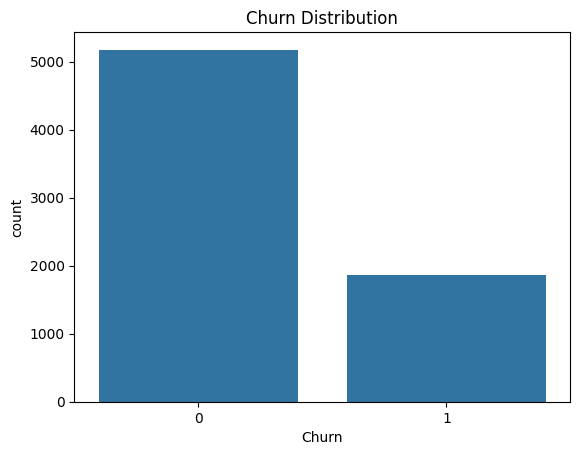

In [ ]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

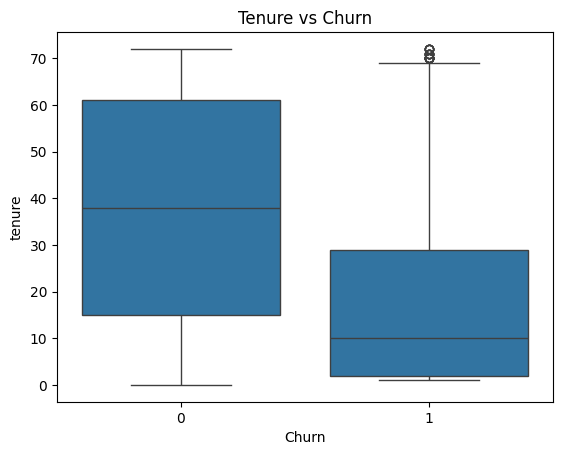

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

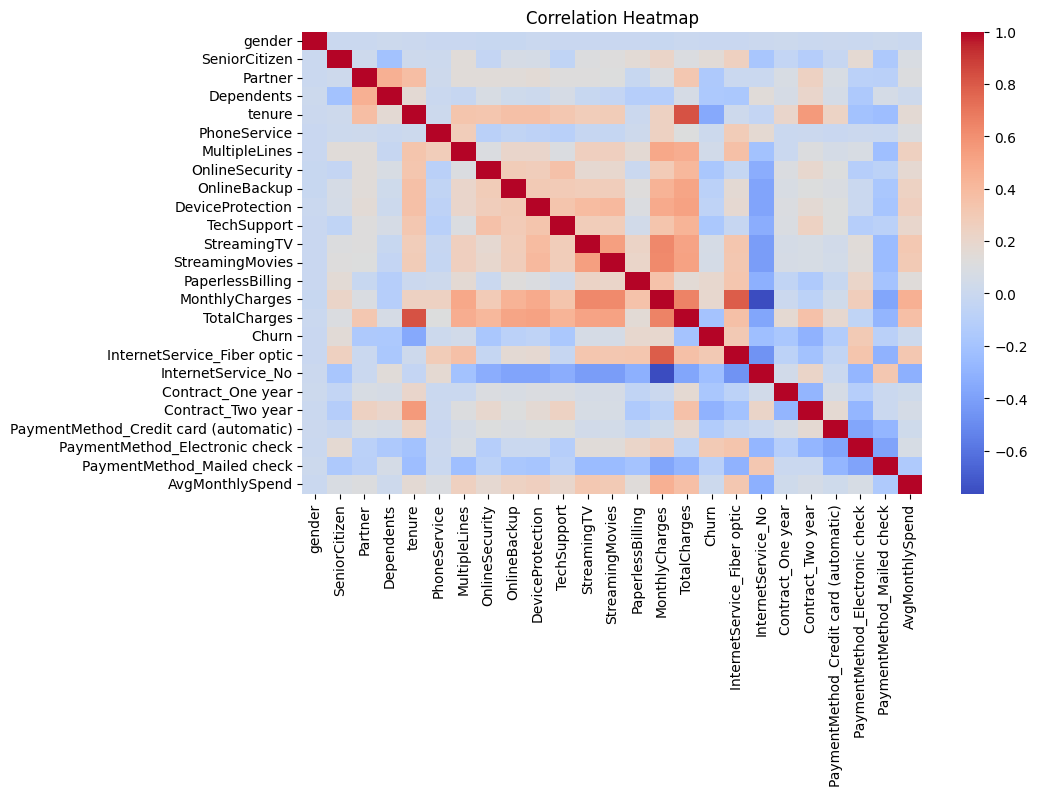

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Section 3 — Train Test Split

In [ ]:
X = df.drop(['Churn','MonthlyCharges'], axis=1)
y_reg = df['MonthlyCharges']
y_clf = df['Churn']

X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=RANDOM_STATE)
_, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=RANDOM_STATE)

## Section 4 — Regression Task

**Q4:** Train Linear Regression and compute RMSE.

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train_reg)

pred_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test_reg, pred_lr))

record_answer('Q4_lr_rmse', rmse_lr)
print(rmse_lr)

1.0484566567398335


Q5: Train a RandomForestRegressor and Compute RMSE

In this question, you will train a Random Forest Regressor using the RandomForestRegressor class from the Scikit-learn (sklearn) library and evaluate its performance using Root Mean Squared Error (RMSE).

Random Forest is an ensemble learning algorithm that builds multiple decision trees during training and combines their predictions to produce the final output. Instead of relying on a single decision tree, Random Forest creates many trees using random subsets of the data (bootstrap sampling). Each tree learns different patterns from the data, and the final prediction for regression problems is obtained by averaging the predictions from all trees. This process helps reduce overfitting and improves model stability.

The RandomForestRegressor model is available in sklearn.ensemble and can be used as follows:

from sklearn.ensemble import RandomForestRegressor

Basic workflow:

1. Initialize the model
model = RandomForestRegressor(n_estimators=100, random_state=42)

2. Train the model using training data
model.fit(X_train, y_train)

3. Predict on test data
y_pred = model.predict(X_test)

Some commonly used parameters in RandomForestRegressor include:

n_estimators:
Number of decision trees in the forest. Increasing this generally improves performance but increases computation time.

max_depth:
Maximum depth of each decision tree. Limiting the depth can help reduce overfitting.

min_samples_split:
Minimum number of samples required to split an internal node.

random_state:
Ensures reproducibility of results.

To evaluate the regression model, we use Root Mean Squared Error (RMSE). RMSE measures the average magnitude of prediction errors.

First compute Mean Squared Error (MSE):

MSE = (1/n) * Σ(y_true − y_pred)^2

Then compute RMSE:

RMSE = sqrt(MSE)

In sklearn this can be computed using:

from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

Task:

1. Split the dataset into training and testing sets using train_test_split.
2. Initialize a RandomForestRegressor model with n_estimators = 100 and random_state = 42.
3. Train the model using the training data.
4. Predict on the test dataset.
5. Compute the RMSE between predicted values and true values.

Print the RMSE value.


In [ ]:
rf_reg = RandomForestRegressor(random_state=RANDOM_STATE)
rf_reg.fit(X_train, y_train_reg)

pred_rf = rf_reg.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, pred_rf))

record_answer('Q5_rf_rmse', rmse_rf)
print(rmse_rf)

1.9352282609333595


**Q6:** Which regression model performs better?

In [ ]:
best_model = 'RandomForest' if rmse_rf < rmse_lr else 'LinearRegression'
record_answer('Q6_best_reg_model', best_model)
print(best_model)

LinearRegression


## Section 5 — Classification Task

**Q7:** Train Logistic Regression and compute accuracy, precision, recall, and F1.

In [ ]:
log_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_model.fit(X_train, y_train_clf)

pred_log = log_model.predict(X_test)

acc = accuracy_score(y_test_clf, pred_log)
precision = precision_score(y_test_clf, pred_log)
recall = recall_score(y_test_clf, pred_log)
f1 = f1_score(y_test_clf, pred_log)

record_answer('Q7_accuracy', acc)
record_answer('Q8_precision', precision)
record_answer('Q9_recall', recall)
record_answer('Q10_f1', f1)

print(acc, precision, recall, f1)

0.8126330731014905 0.6775244299674267 0.5576407506702413 0.611764705882353


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Section 6 — Confusion Matrix

**Q11-Q14:** Extract TP, FP, FN, TN from confusion matrix.

In [ ]:
cm = confusion_matrix(y_test_clf, pred_log)
tn, fp, fn, tp = cm.ravel()

record_answer('Q11_tp', tp)
record_answer('Q12_fp', fp)
record_answer('Q13_fn', fn)
record_answer('Q14_tn', tn)

print(cm)

[[937  99]
 [165 208]]


## Section 7 — ROC Curve Analysis

**Q15:** Compute ROC-AUC score.

In [ ]:
probs = log_model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test_clf, probs)

record_answer('Q15_auc', auc)
print(auc)

0.8623404618712931


**Q16:** Plot ROC Curve (not graded).

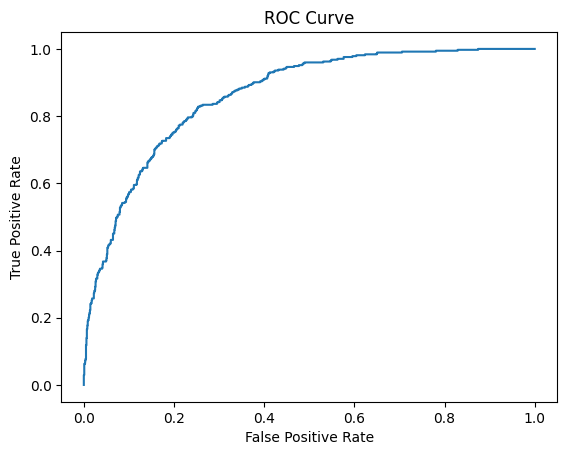

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test_clf, probs)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

## Section 8 — Threshold Tuning

**Q17:** Change classification threshold to 0.3 and compute recall.

In [ ]:
pred_threshold = (probs > 0.3).astype(int)
recall_thresh = recall_score(y_test_clf, pred_threshold)

record_answer('Q17_recall_threshold_03', recall_thresh)
print(recall_thresh)

0.7855227882037533


## Section 9 — Hyperparameter Tuning

Q18: Perform GridSearchCV on RandomForestClassifier (Specify Parameter Range)

In this question, you will use GridSearchCV from Scikit-learn to perform hyperparameter tuning for a RandomForestClassifier.

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions using majority voting for classification tasks. However, the performance of the model depends on the choice of hyperparameters such as the number of trees and the maximum depth of each tree.

GridSearchCV performs an exhaustive search over a specified set of hyperparameter values and evaluates each combination using cross-validation. The model with the best cross-validation score is selected as the best model.

We will tune the following parameters:

1. n_estimators  
   This parameter specifies the number of trees in the forest.  
   Try values in the range: [50, 100, 150]

2. max_depth  
   This parameter controls the maximum depth of each decision tree.  
   Smaller values prevent overfitting but may underfit the data.  
   Try values in the range: [3, 5, 10]

Use 5-fold cross-validation (cv = 5) to evaluate each parameter combination.

Task:

1. Define the parameter grid with the following ranges:
   - n_estimators: [50, 100, 150]
   - max_depth: [3, 5, 10]

2. Initialize GridSearchCV using RandomForestClassifier with random_state = RANDOM_STATE.

3. Fit the model on the training data (X_train, y_train_clf).

4. Retrieve the best parameter combination using grid.best_params_.


In [ ]:
param_grid = {'n_estimators':[50,100], 'max_depth':[3,5,10]}

grid = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), param_grid, cv=5)
grid.fit(X_train, y_train_clf)

record_answer('Q18_best_params', str(grid.best_params_))
print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 100}


## Section 10 — AutoML and Bayesian Optimization

In real-world machine learning projects, building a good model requires:

- choosing an algorithm
- tuning hyperparameters
- testing multiple configurations

This process can be expensive and time-consuming.

**AutoML (Automated Machine Learning)** systems automate this search.

Instead of manually trying combinations, AutoML systems automatically search for:

- good algorithms
- good hyperparameters
- good model pipelines

---

### How AutoML Works (Intuition)

Many AutoML frameworks rely on **Bayesian Optimization**.

Instead of trying random hyperparameters, Bayesian optimization works as follows:

1. Try a few initial models.
2. Observe their performance.
3. Build a probabilistic model of the relationship:

Hyperparameters → Model Performance

4. Use this model to intelligently select the next hyperparameters to evaluate.

This allows the system to **find good models much faster than grid search**.

---

### Meta-Learning

Some AutoML frameworks also use **meta-learning**.

They analyze characteristics of the dataset:

- number of features
- number of samples
- class balance

and use knowledge from **previous datasets** to initialize the search.

---

### References

AutoML overview  
https://www.automl.org/automl/

Hyperopt documentation  
https://hyperopt.github.io/hyperopt/

Bayesian Optimization explanation  
https://towardsdatascience.com/bayesian-optimization

---

In this section you will implement **automated hyperparameter tuning using Hyperopt**.

### Q19 — Hyperparameter Optimization with Hyperopt

Use **Hyperopt** to automatically search for good hyperparameters for a
Random Forest classifier.

Search over the following parameters:

- number of trees (`n_estimators`)
- tree depth (`max_depth`)
- feature selection method (`max_features`)

Use Bayesian optimization to find the best parameters.

Record the **best cross-validation accuracy obtained**.

#Hyperopt Execution

#Imports

In [ ]:
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import numpy as np

#Search Space

In [ ]:
# Define search space (algorithm + hyperparameters)

space = hp.choice("classifier_type", [

    {
        "type": "logistic",

        "C": hp.loguniform("logreg_C", -4, 2)

    },

    {
        "type": "random_forest",

        "n_estimators": hp.choice("rf_n_estimators", [50,100,150]),
        "max_depth": hp.choice("rf_max_depth", [3,5,10,None])

    },

    {
        "type": "gradient_boosting",

        "learning_rate": hp.choice("gb_lr", [0.01,0.05,0.1]),
        "n_estimators": hp.choice("gb_estimators", [50,100,150])

    }

])


#Objective Function

In [ ]:
def objective(params):

    # Select model based on type

    if params["type"] == "logistic":

        model = LogisticRegression(
            C=params["C"],
            max_iter=1000,
            random_state=RANDOM_STATE
        )

    elif params["type"] == "random_forest":

        model = RandomForestClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            random_state=RANDOM_STATE
        )

    else:

        model = GradientBoostingClassifier(
            learning_rate=params["learning_rate"],
            n_estimators=params["n_estimators"],
            random_state=RANDOM_STATE
        )


    score = cross_val_score(
        model,
        X_train,
        y_train_clf,
        cv=3,
        scoring="accuracy"
    ).mean()


    return {
        "loss": -score,
        "status": STATUS_OK
    }



#Intialize Trials

In [ ]:
trials = Trials()

#Run Bayesian Optimization

In [ ]:

best = fmin(

    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials,
    rstate=np.random.default_rng(RANDOM_STATE)

)

  0%|          | 0/20 [00:00<?, ?trial/s, best loss=?]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _

  5%|▌         | 1/20 [00:02<00:42,  2.26s/trial, best loss: -0.8054668086616968]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 10%|█         | 2/20 [00:05<00:49,  2.75s/trial, best loss: -0.8054668086616968]

...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 95%|█████████▌| 19/20 [00:41<00:02,  2.07s/trial, best loss: -0.8065317713880015]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _

100%|██████████| 20/20 [00:44<00:00,  2.21s/trial, best loss: -0.8065317713880015]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



#Extract Best Score

In [ ]:
#trials = Trials()



best_score = -min(trials.losses())

print("Best Cross Validation Accuracy:", best_score)

record_answer("Q19_hyperopt_best_accuracy", best_score)

# best_score = -min(trials.losses())

# print("Best Cross Validation Accuracy:", best_score)

Best Cross Validation Accuracy: 0.8065317713880015


## Final Step — Export Solutions

In [ ]:
solutions_df = pd.DataFrame(solutions)
file_name =str(roll_number)+"_solutions.csv"
solutions_df.to_csv(file_name, index=False)

print('solutions.csv generated successfully!')
solutions_df.head()

solutions.csv generated successfully!


,roll_number,question,answer
0,12345,Q1_samples,7043
1,12345,Q2_features,23
2,12345,Q3_churn_rate,0.26537
3,12345,Q4_lr_rmse,1.048457
4,12345,Q5_rf_rmse,1.935228


In [ ]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgMonthlySpend
0,0,0,1,0,1,0,0,0,1,0,...,29.85,0,False,False,False,False,False,True,False,14.925000
1,1,0,0,0,34,1,0,1,0,1,...,1889.50,0,False,False,True,False,False,False,True,53.985714
2,1,0,0,0,2,1,0,1,1,0,...,108.15,1,False,False,False,False,False,False,True,36.050000
3,1,0,0,0,45,0,0,1,0,1,...,1840.75,0,False,False,True,False,False,False,False,40.016304
4,0,0,0,0,2,1,0,0,0,0,...,151.65,1,True,False,False,False,False,True,False,50.550000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,1,0,1,...,1990.50,0,False,False,True,False,False,False,True,79.620000
7039,0,0,1,1,72,1,1,0,1,1,...,7362.90,0,True,False,True,False,True,False,False,100.861644
7040,0,0,1,1,11,0,0,1,0,0,...,346.45,0,False,False,False,False,False,True,False,28.870833
7041,1,1,1,0,4,1,1,0,0,0,...,306.60,1,True,False,False,False,False,False,True,61.320000


---
# Question 2
The dataset is already loaded for you. Use this dataset to answer all the following questions. Please use **Satisfaction** column for the classification task and use **Flight distance** as the regression task.  
You can take help from the previous example.  
Create a **.csv** file at the end and submit your answer on the submission link provided. You can check how to create the .csv file from previous example. All the code you need is already explained there.  
**Use RANDOM_STATE=42 for all parts where randomness is involved just like the first part**

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/TrivikramUmanath/Great-Learning-Quiz/main/airline.csv"

df = pd.read_csv(url)

In [ ]:
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


**Q1:** How many rows (samples) are in the dataset?

**Q2:** How many features are there excluding the targets `satisfaction` and `Flight Distance`?

**Q3:** What is the distribution of customers on `satisfation` classes?

**Q4:** Train Linear Regression and compute RMSE.

Q5: Train a RandomForestRegressor and Compute RMSE

**Q6:** Which regression model performs better?

**Q7:** Train Logistic Regression and compute accuracy, precision, recall, and F1.

**Q8-Q11:** Extract TP, FP, FN, TN from confusion matrix.

**Q12:** Compute ROC-AUC score.

**Q13:** Plot ROC Curve (not graded).

Q14: Perform GridSearchCV on RandomForestClassifier (Specify Parameter Range)

### Q15 — Hyperparameter Optimization with Hyperopt

Use **Hyperopt** to automatically search for good hyperparameters for a
Random Forest classifier.

Search over the following parameters:

- number of trees (`n_estimators`)
- tree depth (`max_depth`)
- feature selection method (`max_features`)

Use Bayesian optimization to find the best parameters.

Record the **best cross-validation accuracy obtained**.